# Figure 4
## Correlation plots using GTEx and ENCODE results
### Author: Martin Loza
### Date: 25/12/18

Let's plot the combined results from GTEx and ENCODE correlation analyses

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggvenn)
})

# Local variables 
seed = 777
date = "251218"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
gray = "gray50"
text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

encode_results_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENCODE/coexpression_results/ENCODE_coexpression_results_selected_lncRNA_TF_pairs_251216.tsv"
encode_data_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENCODE/selected_gene_pairs/log_normalized_tpm_selected_lncRNA_TF_genes_251216.tsv"
gtex_results_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/GTEx/coexpression_results/GTEx_coexpression_results_selected_lncRNA_TF_pairs_251216.tsv"
gtex_data_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/GTEx/selected_gene_pairs/log_normalized_tpm_selected_lncRNA_TF_genes_251218.tsv"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_Figure_Correlation_ENCODE_GTEx/"
tables_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
# Local Functions



### Load and setup the data

In [2]:
# Load the ENCODE coexpression results
encode_results <- read.table(encode_results_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat("Number of gene pairs: ", nrow(encode_results), "\n")
head(encode_results)

Number of gene pairs:  777 


,gene_pair_id,lncRNA_gene_id,TF_gene_id,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869_ENSG00000284779,ENSG00000099869,ENSG00000284779,0.15254446,0.520842118,0.622606655,0.79558726,2.742561e-05,0.0002767494
2,ENSG00000124915_ENSG00000124920,ENSG00000124915,ENSG00000124920,0.02603510,0.913239471,0.942346705,0.09921048,6.773049e-01,0.7496665890
3,ENSG00000163081_ENSG00000135903,ENSG00000163081,ENSG00000135903,0.08711872,0.714950344,0.789862789,0.14909580,5.304196e-01,0.6253961227
4,ENSG00000163597_ENSG00000284526,ENSG00000163597,ENSG00000284526,0.45853176,0.042012303,0.076092214,0.51684030,1.962607e-02,0.0460801246
5,ENSG00000164621_ENSG00000113658,ENSG00000164621,ENSG00000113658,0.62966915,0.002928728,0.007585405,0.64918355,1.953723e-03,0.0078655079
6,ENSG00000165511_ENSG00000165512,ENSG00000165511,ENSG00000165512,0.63206409,0.002790792,0.007294835,0.48156522,3.156428e-02,0.0666341940


In [3]:
# Load the GTEx coexpression results
gtex_results <- read.table(gtex_results_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat("Number of gene pairs: ", nrow(gtex_results), "\n")
head(gtex_results)

Number of gene pairs:  930 


,gene_pair_id,lncRNA_gene_id,TF_gene_id,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000099869_ENSG00000284779,ENSG00000099869,ENSG00000284779,0.6941562,5.240802e-11,1.275902e-10,0.1086102,3.779769e-01,3.989994e-01
2,ENSG00000124915_ENSG00000124920,ENSG00000124915,ENSG00000124920,0.1554977,2.054372e-01,2.299116e-01,0.8703644,5.524228e-22,3.696066e-21
3,ENSG00000163081_ENSG00000135903,ENSG00000163081,ENSG00000135903,0.8500990,4.760093e-20,2.354727e-19,0.6647782,6.321785e-10,1.373659e-09
4,ENSG00000163597_ENSG00000284526,ENSG00000163597,ENSG00000284526,0.3792864,1.423800e-03,1.924613e-03,0.5249838,4.305883e-06,6.663013e-06
5,ENSG00000164621_ENSG00000113658,ENSG00000164621,ENSG00000113658,0.1412541,2.505610e-01,2.764196e-01,0.1524956,2.144311e-01,2.318848e-01
6,ENSG00000165511_ENSG00000165512,ENSG00000165511,ENSG00000165512,0.5629531,5.819021e-07,1.040710e-06,0.6593503,9.717994e-10,2.077640e-09


Load the expression data of selected gene pairs

In [4]:
# Load the encode expression data
encode_data <- read.table(encode_data_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat("ENCODE expression data dimensions: ", dim(encode_data), "\n")
head(encode_data[, 1:5])

ENCODE expression data dimensions:  2092 21 


,gene_id,chondrocytes_adult,heart_adult,renal_epithelial_adult,liver_adult
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000004848,0.000000000,0.00000000,0.00000000,0.00000000
2,ENSG00000005073,1.011600912,0.00000000,0.73716407,0.00000000
3,ENSG00000005102,0.009950331,0.92821930,0.00000000,0.00000000
4,ENSG00000005436,1.124929597,1.64093658,1.36863943,1.15688120
5,ENSG00000005513,0.254642218,0.04879016,0.03922071,0.01980263
6,ENSG00000005801,0.887891257,1.60140574,2.18154676,0.90421815


In [5]:
# Load the GTEx expression data
gtex_data <- read.table(gtex_data_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
# Change the first column name to "gene_id"
colnames(gtex_data)[1] <- "gene_id"
cat("GTEx expression data dimensions: ", dim(gtex_data), "\n")
head(gtex_data[, 1:5])

GTEx expression data dimensions:  2058 69 


,gene_id,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000272438,0.06808566,0.1234452,0.27456568,0.2352768
2,ENSG00000223764,0.46315775,0.9997234,1.60198420,1.9059241
3,ENSG00000187634,0.39083866,1.3746670,1.58750105,1.9401048
4,ENSG00000272512,1.82029833,1.5857946,0.49259098,2.2775975
5,ENSG00000188290,3.16147126,3.2602481,1.38873139,3.8918407
6,ENSG00000197921,0.23182734,0.3240786,0.02956657,0.3727732


Load the gene_pairs original information to recover interesting gene patterns

In [21]:
gene_pairs_file = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/unique/human_unique_lncRNA_TF_pairs_10000bp_251215.tsv"
gene_pairs <- read.table(gene_pairs_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
cat("Number of gene pairs: ", nrow(gene_pairs), "\n")
head(gene_pairs)
colnames(gene_pairs)

Number of gene pairs:  1978 


,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,⋯,Family,is_TF,abs_strand_distance,ncrna_gene_id,pcg_gene_id,gene_pair_id,gene_name_pair_id,ncrna_is_mane,tf_is_mane,mane_priority
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<lgl>,<int>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>
1,11,ENST00000381363,2140644,IGF2-AS,1,lncRNA,ENST00000643349,unnamed,2149603,8959,⋯,ZBTB,TRUE,8959,ENSG00000099869,ENSG00000284779,ENSG00000099869_ENSG00000284779,IGF2-AS_unnamed,FALSE,FALSE,4
2,11,ENST00000833483,61756482,MYRF-AS1,-1,lncRNA,ENST00000265460,MYRF,61755389,-1093,⋯,NDT80_PhoG,TRUE,1093,ENSG00000124915,ENSG00000124920,ENSG00000124915_ENSG00000124920,MYRF-AS1_MYRF,FALSE,FALSE,4
3,2,ENST00000440903,222302978,CCDC140,1,lncRNA,ENST00000392070,PAX3,222298998,-3980,⋯,PAX,TRUE,3980,ENSG00000163081,ENSG00000135903,ENSG00000163081_ENSG00000135903,CCDC140_PAX3,FALSE,TRUE,2
4,17,ENST00000738117,76562607,SNHG16,1,lncRNA,ENST00000713548,unnamed,76569648,7041,⋯,ZBTB,TRUE,7041,ENSG00000163597,ENSG00000284526,ENSG00000163597_ENSG00000284526,SNHG16_unnamed,FALSE,TRUE,2
5,5,ENST00000809704,136132805,SMAD5-AS1,-1,lncRNA,ENST00000545279,SMAD5,136132845,40,⋯,MH1,TRUE,40,ENSG00000164621,ENSG00000113658,ENSG00000164621_ENSG00000113658,SMAD5-AS1_SMAD5,FALSE,TRUE,2
6,10,ENST00000625168,45000920,ZNF22-AS1,-1,lncRNA,ENST00000298299,ZNF22,45000923,3,⋯,zf-C2H2,TRUE,3,ENSG00000165511,ENSG00000165512,ENSG00000165511_ENSG00000165512,ZNF22-AS1_ZNF22,FALSE,TRUE,2


[1] "chromosome"          "ncRNA_id"            "ncrna_tss"          
 [4] "ncrna_gene_name"     "ncrna_strand"        "gene_biotype"       
 [7] "pcg_id"              "pcg_gene_name"       "pcg_tss"            
[10] "dna_distance"        "strand_distance"     "Family"             
[13] "is_TF"               "abs_strand_distance" "ncrna_gene_id"      
[16] "pcg_gene_id"         "gene_pair_id"        "gene_name_pair_id"  
[19] "ncrna_is_mane"       "tf_is_mane"          "mane_priority"

### Analysis

Let's select significant gene pairs within each dataset

In [7]:
# Select significant pairs based on adjusted p-value
adjusted_pvalue_threshold <- 0.05
selected_encode <- encode_results %>%
    filter(pearson_fdr <= adjusted_pvalue_threshold & spearman_fdr <= adjusted_pvalue_threshold)

selected_gtex <- gtex_results %>%
    filter(pearson_fdr <= adjusted_pvalue_threshold & spearman_fdr <= adjusted_pvalue_threshold)

cat("Number of significant gene pairs in ENCODE: ", nrow(selected_encode), "\n")
cat("Number of significant gene pairs in GTEx: ", nrow(selected_gtex), "\n")

Number of significant gene pairs in ENCODE:  295 
Number of significant gene pairs in GTEx:  751 


Now, let's select the significant pairs across datasets

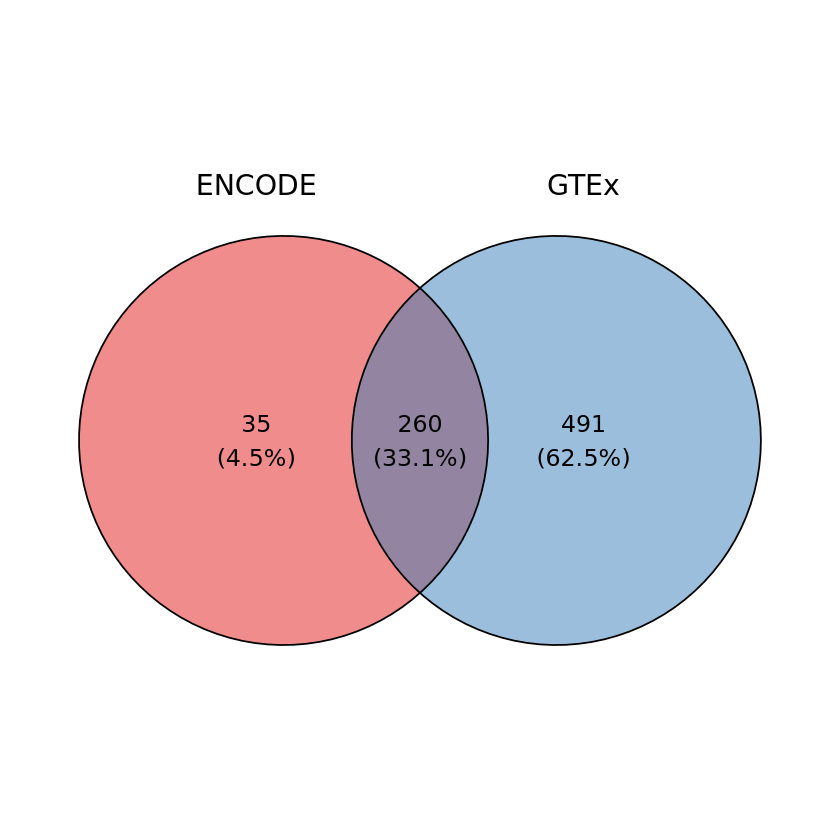

In [8]:
# Create a list with gene_pair_id from both datasets
venn_list <- list(
    ENCODE = selected_encode$gene_pair_id,
    GTEx = selected_gtex$gene_pair_id
)

# Create Venn diagram
venn_plot <- ggvenn(venn_list, 
                    fill_color = c(red, blue),
                    stroke_size = 0.5,
                    set_name_size = 6,
                    text_size = 5)

# Display the plot
print(venn_plot)

In [9]:
# Save the plot
ggsave(filename = paste0(out_dir, "Plots/Venn_diagram_gtex_encode_", date, ".pdf"),
       plot = venn_plot,
       width = width * 0.3, height = 5.0, dpi = dpi)

Let's get the common pairs 

In [10]:
# Get the intersection of gene pairs
common_pairs <- intersect(selected_encode$gene_pair_id, selected_gtex$gene_pair_id)
cat("Number of common significant gene pairs: ", length(common_pairs), "\n")

Number of common significant gene pairs:  260 


Let's save them for GO analysis

In [11]:
tmp_common_pairs <- selected_encode %>%
    filter(gene_pair_id %in% common_pairs) %>%
    select(TF_gene_id)
updated_date <- "260119"
# save the list of TF genes
write.table(tmp_common_pairs, 
        file = paste0(out_dir, "Results/common_significant_TF_genes_", updated_date, ".tsv"), 
        sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)

### Correlation analysis of shared pairs

Let's analyze the correlation values for the shared gene pairs

In [12]:
# Filter results to get only common pairs
encode_common <- selected_encode %>%
    filter(gene_pair_id %in% common_pairs)

gtex_common <- selected_gtex %>%
    filter(gene_pair_id %in% common_pairs)

# Merge the results
merged_results <- encode_common %>%
    left_join(gtex_common, by = "gene_pair_id", suffix = c("_encode", "_gtex"))

cat("Merged results dimensions: ", dim(merged_results), "\n")
cat("Column names: ", colnames(merged_results), "\n")
head(merged_results)

Merged results dimensions:  260 17 
Column names:  gene_pair_id lncRNA_gene_id_encode TF_gene_id_encode pearson_correlation_encode pearson_pvalue_encode pearson_fdr_encode spearman_correlation_encode spearman_pvalue_encode spearman_fdr_encode lncRNA_gene_id_gtex TF_gene_id_gtex pearson_correlation_gtex pearson_pvalue_gtex pearson_fdr_gtex spearman_correlation_gtex spearman_pvalue_gtex spearman_fdr_gtex 


,gene_pair_id,lncRNA_gene_id_encode,TF_gene_id_encode,pearson_correlation_encode,pearson_pvalue_encode,pearson_fdr_encode,spearman_correlation_encode,spearman_pvalue_encode,spearman_fdr_encode,lncRNA_gene_id_gtex,TF_gene_id_gtex,pearson_correlation_gtex,pearson_pvalue_gtex,pearson_fdr_gtex,spearman_correlation_gtex,spearman_pvalue_gtex,spearman_fdr_gtex
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000166770_ENSG00000198046,ENSG00000166770,ENSG00000198046,0.7384413,2.008462e-04,7.962118e-04,0.7301468,2.572352e-04,1.580054e-03,ENSG00000166770,ENSG00000198046,0.9558693,7.946649e-37,1.508242e-35,0.9660266,1.663784e-40,1.406654e-38
2,ENSG00000167912_ENSG00000198846,ENSG00000167912,ENSG00000198846,0.8548898,1.580584e-06,1.292752e-05,0.7996247,2.328468e-05,2.444891e-04,ENSG00000167912,ENSG00000198846,0.9445745,1.225025e-33,1.604611e-32,0.9421308,4.892925e-33,1.191716e-31
3,ENSG00000176593_ENSG00000166704,ENSG00000176593,ENSG00000166704,0.8665018,7.799795e-07,6.659825e-06,0.8337098,4.965214e-06,6.768371e-05,ENSG00000176593,ENSG00000166704,0.8723560,3.425095e-22,1.954196e-21,0.8267359,3.827636e-18,1.893458e-17
4,ENSG00000177133_ENSG00000142611,ENSG00000177133,ENSG00000142611,0.8947618,1.020600e-07,1.166185e-06,0.5982659,5.328015e-03,1.649350e-02,ENSG00000177133,ENSG00000142611,0.9015454,1.050489e-25,7.692560e-25,0.9464824,3.974843e-34,1.192453e-32
5,ENSG00000177738_ENSG00000172262,ENSG00000177738,ENSG00000172262,0.5705344,8.616182e-03,1.951829e-02,0.6255639,3.178355e-03,1.142145e-02,ENSG00000177738,ENSG00000172262,0.7994074,3.019127e-16,1.079918e-15,0.8163912,2.177107e-17,9.641472e-17
6,ENSG00000181097_ENSG00000181135,ENSG00000181097,ENSG00000181135,0.5882138,6.372868e-03,1.514287e-02,0.5872897,6.476816e-03,1.943045e-02,ENSG00000181097,ENSG00000181135,0.8648001,2.016364e-21,1.103070e-20,0.9047601,3.701189e-26,4.097745e-25


#### Scatter plots comparing correlations across datasets

Warning message in annotate("label", x = 0.8, y = 0.5, label = paste0("R = ", pearson_r, :
“Ignoring unknown parameters: `label.size`”
Warning message in annotate("label", x = 0.8, y = 0.5, label = paste0("R = ", spearman_r, :
“Ignoring unknown parameters: `label.size`”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


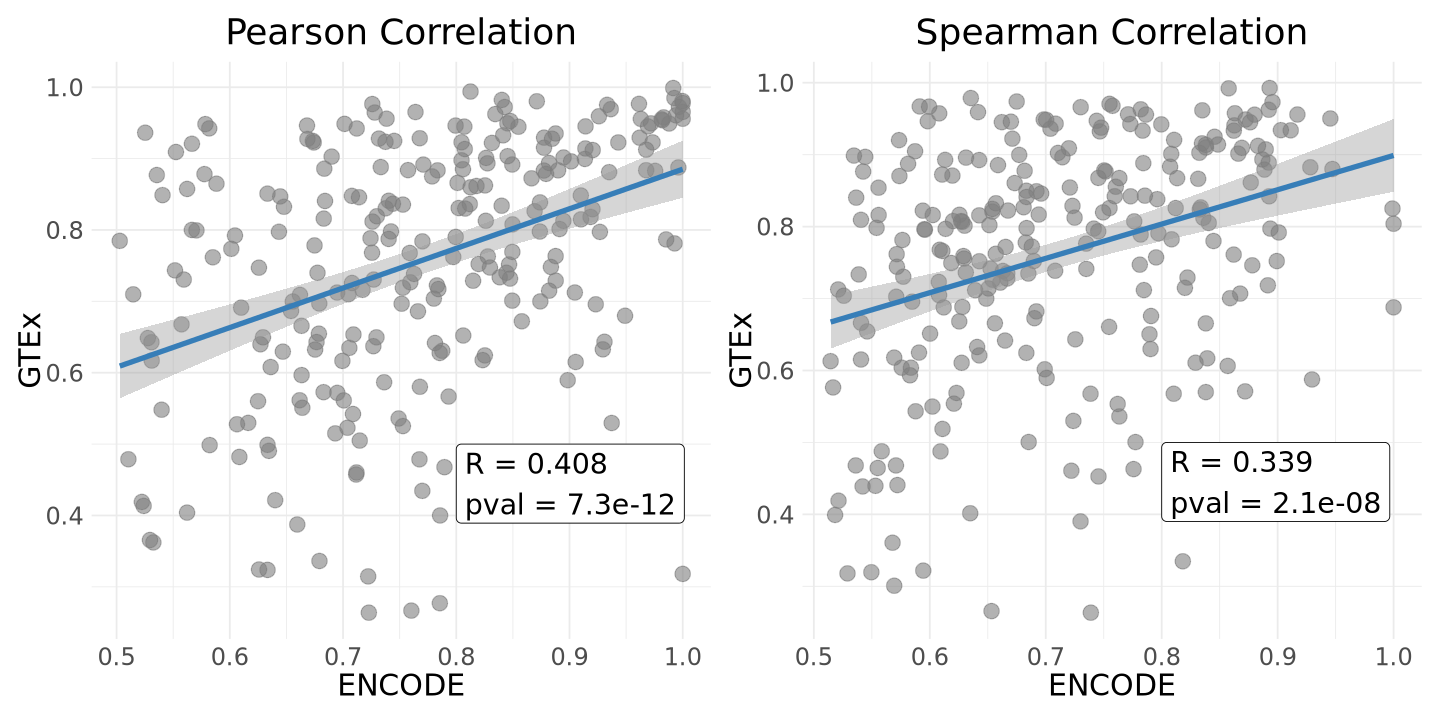

In [13]:
tmp_df <- merged_results %>%
    select(gene_pair_id, pearson_correlation_encode, spearman_correlation_encode, pearson_correlation_gtex, spearman_correlation_gtex) 

# Calculate correlation statistics 
pearson_test <- cor.test(tmp_df$pearson_correlation_encode, tmp_df$pearson_correlation_gtex, method = "pearson")
pearson_r <- round(pearson_test$estimate, 3)
pearson_p <- format.pval(pearson_test$p.value, digits = 2)

spearman_test <- cor.test(tmp_df$spearman_correlation_encode, tmp_df$spearman_correlation_gtex, method = "pearson")
spearman_r <- round(spearman_test$estimate, 3)
spearman_p <- format.pval(spearman_test$p.value, digits = 2)

# Create scatter plot for Pearson correlations
p_pearson <- ggplot(tmp_df, aes(x = pearson_correlation_encode, y = pearson_correlation_gtex)) +
    geom_point(color = gray, size = dot_size, alpha = 0.6) +
    geom_smooth(method = "lm", color = blue, linewidth = line_size, se = TRUE) +
    annotate("label", x = 0.80, y = 0.5, 
             label = paste0("R = ", pearson_r, "\npval = ", pearson_p),
             hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
    labs(x = "ENCODE", 
         y = "GTEx",
         title = "Pearson Correlation") +
    theme_minimal() +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          plot.title = element_text(hjust = 0.5))

# Create scatter plot for Spearman correlations
p_spearman <- ggplot(tmp_df, aes(x = spearman_correlation_encode, y = spearman_correlation_gtex)) +
    geom_point(color = gray, size = dot_size, alpha = 0.6) +
    geom_smooth(method = "lm", color = blue, linewidth = line_size, se = TRUE) +
    annotate("label", x = 0.80, y = 0.5, 
             label = paste0("R = ", spearman_r, "\npval = ", spearman_p),
             hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
    labs(x = "ENCODE", 
         y = "GTEx",
         title = "Spearman Correlation") +
    theme_minimal() +
    theme(text = element_text(size = text_size),
          strip.text = element_text(size = text_size + 1),
          plot.title = element_text(hjust = 0.5))

# Combine plots
p_corr_comparison <- (p_pearson | p_spearman) 


# Change plot size
options(repr.plot.width=12, repr.plot.height=6)
print(p_corr_comparison)

In [ ]:
# Save correlation comparison plot
ggsave(filename = paste0(out_dir, "Plots/correlation_comparison_encode_gtex_", date, ".pdf"),
       plot = p_corr_comparison,
       width = width * 0.6, height = 5.0, units = "in", dpi = dpi)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


#### Overall ranking of gene pairs

Calculate an overall rank combining both datasets and both methods

In [14]:
# Calculate overall rank based on average of absolute correlations
merged_results <- merged_results %>%
    mutate(
        avg_correlation = (abs(pearson_correlation_encode) + abs(spearman_correlation_encode) + 
                          abs(pearson_correlation_gtex) + abs(spearman_correlation_gtex)) / 4,
        overall_rank = rank(-avg_correlation, ties.method = "first")
    ) %>%
    arrange(overall_rank)


Let's transfer the gene name information

In [16]:
colnames(merged_results)

[1] "gene_pair_id"                "lncRNA_gene_id_encode"      
 [3] "TF_gene_id_encode"           "pearson_correlation_encode" 
 [5] "pearson_pvalue_encode"       "pearson_fdr_encode"         
 [7] "spearman_correlation_encode" "spearman_pvalue_encode"     
 [9] "spearman_fdr_encode"         "lncRNA_gene_id_gtex"        
[11] "TF_gene_id_gtex"             "pearson_correlation_gtex"   
[13] "pearson_pvalue_gtex"         "pearson_fdr_gtex"           
[15] "spearman_correlation_gtex"   "spearman_pvalue_gtex"       
[17] "spearman_fdr_gtex"           "avg_correlation"            
[19] "overall_rank"

In [22]:
# sel_cols <- c('gene_pair_id','chromosome','ncrna_strand','gene_biotype','Family','gene_name_pair_id')
sel_cols <- c('gene_pair_id','chromosome','gene_biotype','Family','gene_name_pair_id')
selected_gene_pairs <- gene_pairs %>%
    select(all_of(sel_cols))

# Transfer the avg_correlation and overall_rank to selected_gene_pairs
sel_cols <- c("gene_pair_id", "avg_correlation", "overall_rank",
    "pearson_correlation_encode", "pearson_pvalue_encode","pearson_fdr_encode",
    "spearman_correlation_encode", "spearman_pvalue_encode", "spearman_fdr_encode",
    "pearson_correlation_gtex", "pearson_pvalue_gtex", "pearson_fdr_gtex", 
    "spearman_correlation_gtex", "spearman_pvalue_gtex", "spearman_fdr_gtex")
selected_gene_pairs <- selected_gene_pairs %>%
    left_join(merged_results %>% select(all_of(sel_cols)), by = "gene_pair_id") %>%
    filter(!is.na(overall_rank)) %>%
    arrange(overall_rank)

dim(selected_gene_pairs)
head(selected_gene_pairs)


[1] 260  19

,gene_pair_id,chromosome,gene_biotype,Family,gene_name_pair_id,avg_correlation,overall_rank,pearson_correlation_encode,pearson_pvalue_encode,pearson_fdr_encode,spearman_correlation_encode,spearman_pvalue_encode,spearman_fdr_encode,pearson_correlation_gtex,pearson_pvalue_gtex,pearson_fdr_gtex,spearman_correlation_gtex,spearman_pvalue_gtex,spearman_fdr_gtex
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000227640_ENSG00000125285,13,lncRNA,HMG,SOX21-AS1_SOX21,0.9682961,1,0.9926493,5.793868e-18,2.501020e-16,0.9454347,3.338097e-10,5.187402e-08,0.9848206,6.355812e-52,4.222075e-50,0.9502797,3.722081e-35,1.442306e-33
2,ENSG00000263146_ENSG00000256463,18,lncRNA,zf-C2H2,LINC01896_SALL3,0.9499586,2,0.9940421,8.791072e-19,4.553775e-17,0.9113053,2.329842e-08,2.011430e-06,0.9606540,1.942584e-38,4.201403e-37,0.9338331,3.566871e-31,6.504294e-30
3,ENSG00000277268_ENSG00000273706,17,lncRNA,Homeobox,LHX1-DT_LHX1,0.9465009,3,0.9916061,1.905756e-17,7.793540e-16,0.8622071,1.020307e-06,2.157177e-05,0.9988611,6.030140e-89,9.346717e-87,0.9333293,4.544709e-31,7.974679e-30
4,ENSG00000236502_ENSG00000138083,2,lncRNA,Homeobox,SIX3-AS1_SIX3,0.9460684,4,0.9997509,3.499897e-31,4.532366e-29,1.0000000,0.000000e+00,0.000000e+00,0.9806077,1.927173e-48,8.961355e-47,0.8039150,1.540551e-16,6.283827e-16
5,ENSG00000255399_ENSG00000089225,12,lncRNA,T-box,TBX5-AS1_TBX5,0.9433313,5,0.9630031,1.078286e-11,2.393795e-10,0.8923395,1.241187e-07,5.366357e-06,0.9555699,9.885933e-37,1.802729e-35,0.9624127,4.416666e-39,3.159615e-37
6,ENSG00000240990_ENSG00000005073,7,lncRNA,Homeobox,HOXA11-AS_HOXA11,0.9392763,6,0.9720047,9.063157e-13,2.347358e-11,0.8801290,3.116881e-07,1.009090e-05,0.9493641,6.698552e-35,1.092922e-33,0.9556072,9.621740e-37,4.261056e-35


In [23]:
# Save the Supplementary Table with ranked gene pairs
# tmp_table <- selected_gene_pairs %>% select(gene_pair_id, gene_name_pair_id, Family, avg_correlation, overall_rank) %>%
#     dplyr::rename(lncRNA_Family = Family) %>%
#     mutate(is_DT = ifelse(str_detect(gene_name_pair_id, "DT"), TRUE, FALSE)) %>%
#     mutate(is_AS = ifelse(str_detect(gene_name_pair_id, "AS"), TRUE, FALSE))

# tmp_table %>% filter(overall_rank <= 50) %>%
#     count(is_DT, is_AS)

# save supplementary table
write.table(selected_gene_pairs, file = paste0(tables_out_dir, "Supplementary_table_ranked_lncRNA_TF_gene_pairs_", date,".tsv"),
            sep = "\t", row.names = FALSE, quote = FALSE)

In [40]:
# Create supplementary tables showing the Family distribution for all selected gene pairs and for the top 50 pairs

# Table for all selected gene pairs
all_family_counts <- selected_gene_pairs %>%
    group_by(Family) %>%
    summarise(n_pairs = n()) %>%
    arrange(desc(n_pairs))

cat("Family distribution for all", nrow(selected_gene_pairs), "selected gene pairs:\n")
print(all_family_counts)

Family distribution for all 260 selected gene pairs:
# A tibble: 42 × 2
   Family    n_pairs
   <chr>       <int>
 1 zf-C2H2        70
 2 Homeobox       67
 3 bHLH           12
 4 Fork_head      11
 5 ZBTB           11
 6 HMG             8
 7 Others          8
 8 Pou             8
 9 TF_bZIP         6
10 RXR-like        5
# ℹ 32 more rows


In [41]:
# Table for top 50 gene pairs
top50_family_counts <- selected_gene_pairs %>%
    filter(overall_rank <= 50) %>%
    group_by(Family) %>%
    summarise(n_pairs = n()) %>%
    arrange(desc(n_pairs))

cat("Family distribution for top 50 gene pairs:\n")
print(top50_family_counts)

Family distribution for top 50 gene pairs:
# A tibble: 12 × 2
   Family    n_pairs
   <chr>       <int>
 1 Homeobox       22
 2 zf-C2H2        10
 3 bHLH            4
 4 Fork_head       3
 5 HMG             3
 6 zf-GATA         2
 7 ETS             1
 8 Pou             1
 9 RXR-like        1
10 SAND            1
11 T-box           1
12 ZBTB            1


In [42]:

# Save the tables
write.table(all_family_counts, 
            file = paste0(tables_out_dir, "Supplementary_Table_family_distribution_all_coexpressing_pairs_", date, ".tsv"),
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(top50_family_counts, 
            file = paste0(tables_out_dir, "Supplementary_Table_family_distribution_top50_coexpressing_pairs_", date, ".tsv"),
            sep = "\t", row.names = FALSE, quote = FALSE)


cat("Tables saved successfully!\n")

Tables saved successfully!


#### Expression plots for top-ranked pairs (one from each of the top 3 families)

Create scatter plots showing coexpression patterns for top pairs from the most represented families

In [43]:
# Get one top gene from three different families
plot_gene_pairs <- selected_gene_pairs %>% filter(overall_rank <= 50) %>%
    group_by(Family) %>%
    arrange(overall_rank) %>%
    slice_head(n = 1) %>%
    ungroup() %>%
    arrange(overall_rank) %>%
    slice_head(n = 3)

plot_gene_pairs <- as.data.frame(plot_gene_pairs)

# Let's recover the indenpendent gene_ids; they are separated by "_" in the gene_name_pair_id column
plot_gene_pairs$gene_id_1 <- sapply(str_split(plot_gene_pairs$gene_pair_id, "_"), `[`, 1)
plot_gene_pairs$gene_id_2 <- sapply(str_split(plot_gene_pairs$gene_pair_id, "_"), `[`, 2)
# Let's also recover the gene names
plot_gene_pairs$gene_name_1 <- sapply(str_split(plot_gene_pairs$gene_name_pair_id, "_"), `[`, 1)
plot_gene_pairs$gene_name_2 <- sapply(str_split(plot_gene_pairs$gene_name_pair_id, "_"), `[`, 2)

cat("\nTop 3 pairs from each of the top 3 families:\n")
plot_gene_pairs


Top 3 pairs from each of the top 3 families:


gene_pair_id,chromosome,ncrna_strand,gene_biotype,Family,gene_name_pair_id,avg_correlation,overall_rank,gene_id_1,gene_id_2,gene_name_1,gene_name_2
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
ENSG00000227640_ENSG00000125285,13,1,lncRNA,HMG,SOX21-AS1_SOX21,0.9682961,1,ENSG00000227640,ENSG00000125285,SOX21-AS1,SOX21
ENSG00000263146_ENSG00000256463,18,-1,lncRNA,zf-C2H2,LINC01896_SALL3,0.9499586,2,ENSG00000263146,ENSG00000256463,LINC01896,SALL3
ENSG00000277268_ENSG00000273706,17,-1,lncRNA,Homeobox,LHX1-DT_LHX1,0.9465009,3,ENSG00000277268,ENSG00000273706,LHX1-DT,LHX1


Now, let's recover the expression data for the selected gene pairs

In [44]:
head(encode_data)

,gene_id,chondrocytes_adult,heart_adult,renal_epithelial_adult,liver_adult,osteoblasts_adult,cardiac_fibroblasts_adult,ovary_adult,vagina_adult,lung_fibroblasts_adult,⋯,aorta_adult,uterus_adult,tongue_embryonic,frontal_cortex_embryonic,spinal_cord_embryonic,eye_embryonic,stomach_embryonic,lung_embryonic,liver_embryonic,kidney_epithelial_embryonic
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000004848,0.000000000,0.00000000,0.00000000,0.00000000,0.0000000,0.000000000,1.12492960,0.0000000,0.0000000,⋯,0.0000000,0.0000000,0.0295588,0.139761942,0.0000000,0.095310180,0.009950331,0.01980263,0.00000000,0.0000000
2,ENSG00000005073,1.011600912,0.00000000,0.73716407,0.00000000,0.3506569,0.000000000,0.01980263,0.3364722,0.0000000,⋯,0.0000000,1.2470323,0.0000000,0.000000000,0.1988509,0.009950331,0.000000000,0.00000000,0.00000000,1.6370531
3,ENSG00000005102,0.009950331,0.92821930,0.00000000,0.00000000,0.0000000,0.009950331,0.08617770,0.1739533,0.0000000,⋯,0.9820785,0.2390169,1.0079579,0.009950331,0.2070142,0.887891257,0.246860078,0.34358970,0.06765865,0.4824261
4,ENSG00000005436,1.124929597,1.64093658,1.36863943,1.15688120,0.4317824,1.128171091,1.26694760,0.8960880,0.3435897,⋯,1.3635374,0.6830968,1.4398351,0.392042088,1.4350845,2.111424588,1.217875709,2.81959158,1.49514877,1.7491999
5,ENSG00000005513,0.254642218,0.04879016,0.03922071,0.01980263,0.0000000,0.198850859,0.01980263,0.0295588,0.0000000,⋯,1.0224509,0.0000000,1.8594181,0.444685821,2.0095554,2.452727751,0.165514438,0.87129337,0.06765865,0.1570037
6,ENSG00000005801,0.887891257,1.60140574,2.18154676,0.90421815,0.4252677,1.141033005,1.18172720,0.4252677,0.7030975,⋯,0.1133287,0.3576744,0.9593502,0.751416089,1.5933085,2.467251715,0.940007258,2.43449016,1.14103300,2.9101744


In [45]:
plot_list <- list()

for(i in 1:nrow(plot_gene_pairs)) {
    gene_id_1 <- plot_gene_pairs$gene_id_1[i]
    gene_id_2 <- plot_gene_pairs$gene_id_2[i]
    gene_name_1 <- plot_gene_pairs$gene_name_1[i]
    gene_name_2 <- plot_gene_pairs$gene_name_2[i]
    family <- plot_gene_pairs$Family[i]
    gene_pair_id <- plot_gene_pairs$gene_pair_id[i]
    avg_corr <- plot_gene_pairs$avg_correlation[i]
    
    # Get expression data for the two genes from ENCODE
    expr_gene_1 <- encode_data %>%
        filter(gene_id == gene_id_1) %>%
        select(-gene_id) %>%
        unlist(use.names = FALSE)
    
    expr_gene_2 <- encode_data %>%
        filter(gene_id == gene_id_2) %>%
        select(-gene_id) %>%
        unlist(use.names = FALSE)
    
    # Create a data frame for plotting
    plot_df <- data.frame(
        Expression_Gene_1 = expr_gene_1,
        Expression_Gene_2 = expr_gene_2
    )
    
    # Create scatter plot
    p <- ggplot(plot_df, aes(x = Expression_Gene_1, y = Expression_Gene_2)) +
        geom_point(color = gray, size = dot_size, alpha = 0.6) +
        geom_smooth(method = "lm", color = blue, linewidth = line_size, se = TRUE) +
        annotate("label", x = 0.01, y = Inf,
                 label = paste0("Rank = ", i, "\n",
                    "Avg correlation = ", round(avg_corr, 3), "\n",
                    "Family = ", family), size = 6,
                 hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
        labs(x =  paste0( gene_name_1, " log(TPM+1)"),
             y = paste0( gene_name_2, "  log(TPM+1)")) +
        theme_minimal() +
        theme(text = element_text(size = text_size),
              strip.text = element_text(size = text_size + 1),
              plot.title = element_text(hjust = 0.5))
    
    plot_list[[i]] <- p
}
#  plot_list[[1]]

Warning message:
“Duplicated aesthetics after name standardisation: size”
Warning message:
“Duplicated aesthetics after name standardisation: size”
Warning message:
“Duplicated aesthetics after name standardisation: size”


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


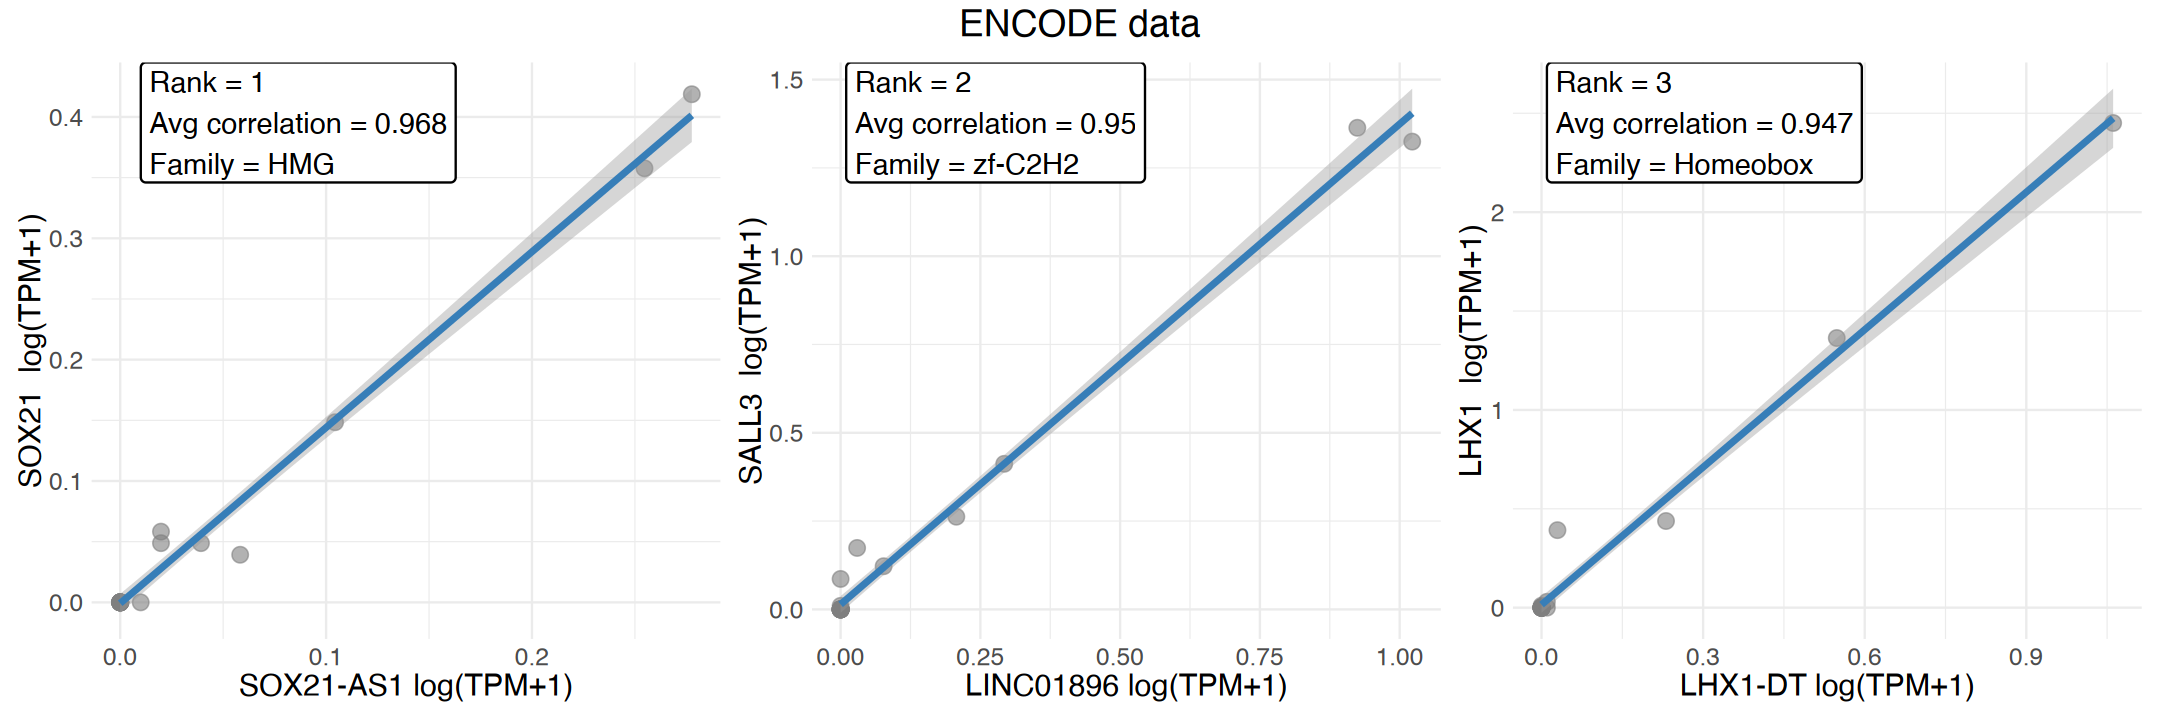

In [46]:
# change the plot size
options(repr.plot.width=18, repr.plot.height=6)
p_genes_encode <- wrap_plots(plot_list, nrow = 1) + plot_annotation(title = "ENCODE data",
                                                        theme = theme(plot.title = element_text(size = text_size + 4, hjust = 0.5)))
print(p_genes_encode)

In [ ]:
# save the plot
ggsave(filename = paste0(out_dir, "Plots/Correlation_plots_top3_encode_", date, ".pdf"),
       plot = p_genes_encode,
       width = width*0.9, height = height, units = "in", dpi = dpi)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [48]:
plot_list <- list()

for(i in 1:nrow(plot_gene_pairs)) {
    gene_id_1 <- plot_gene_pairs$gene_id_1[i]
    gene_id_2 <- plot_gene_pairs$gene_id_2[i]
    gene_name_1 <- plot_gene_pairs$gene_name_1[i]
    gene_name_2 <- plot_gene_pairs$gene_name_2[i]
    family <- plot_gene_pairs$Family[i]
    gene_pair_id <- plot_gene_pairs$gene_pair_id[i]
    avg_corr <- plot_gene_pairs$avg_correlation[i]
    
    # Get expression data for the two genes from ENCODE
    expr_gene_1 <- gtex_data %>%
        filter(gene_id == gene_id_1) %>%
        select(-gene_id) %>%
        unlist(use.names = FALSE)
    
    expr_gene_2 <- gtex_data %>%
        filter(gene_id == gene_id_2) %>%
        select(-gene_id) %>%
        unlist(use.names = FALSE)
    
    # Create a data frame for plotting
    plot_df <- data.frame(
        Expression_Gene_1 = expr_gene_1,
        Expression_Gene_2 = expr_gene_2
    )
    
    # Create scatter plot
    p <- ggplot(plot_df, aes(x = Expression_Gene_1, y = Expression_Gene_2)) +
        geom_point(color = gray, size = dot_size, alpha = 0.6) +
        geom_smooth(method = "lm", color = blue, linewidth = line_size, se = TRUE) +
        annotate("label", x = 0.01, y = Inf,
                 label = paste0("Rank = ", i, "\n",
                    "Avg correlation = ", round(avg_corr, 3), "\n",
                    "Family = ", family), size = 6,
                 hjust = 0, vjust = 1, size = 6,
             fill = "white", color = "black", label.size = 0.5) +
        labs(x =  paste0( gene_name_1, " log(TPM+1)"),
             y = paste0( gene_name_2, "  log(TPM+1)")) +
        theme_minimal() +
        theme(text = element_text(size = text_size),
              strip.text = element_text(size = text_size + 1),
              plot.title = element_text(hjust = 0.5))
    
    plot_list[[i]] <- p
}
#  plot_list[[1]]

Warning message:
“Duplicated aesthetics after name standardisation: size”
Warning message:
“Duplicated aesthetics after name standardisation: size”
Warning message:
“Duplicated aesthetics after name standardisation: size”


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


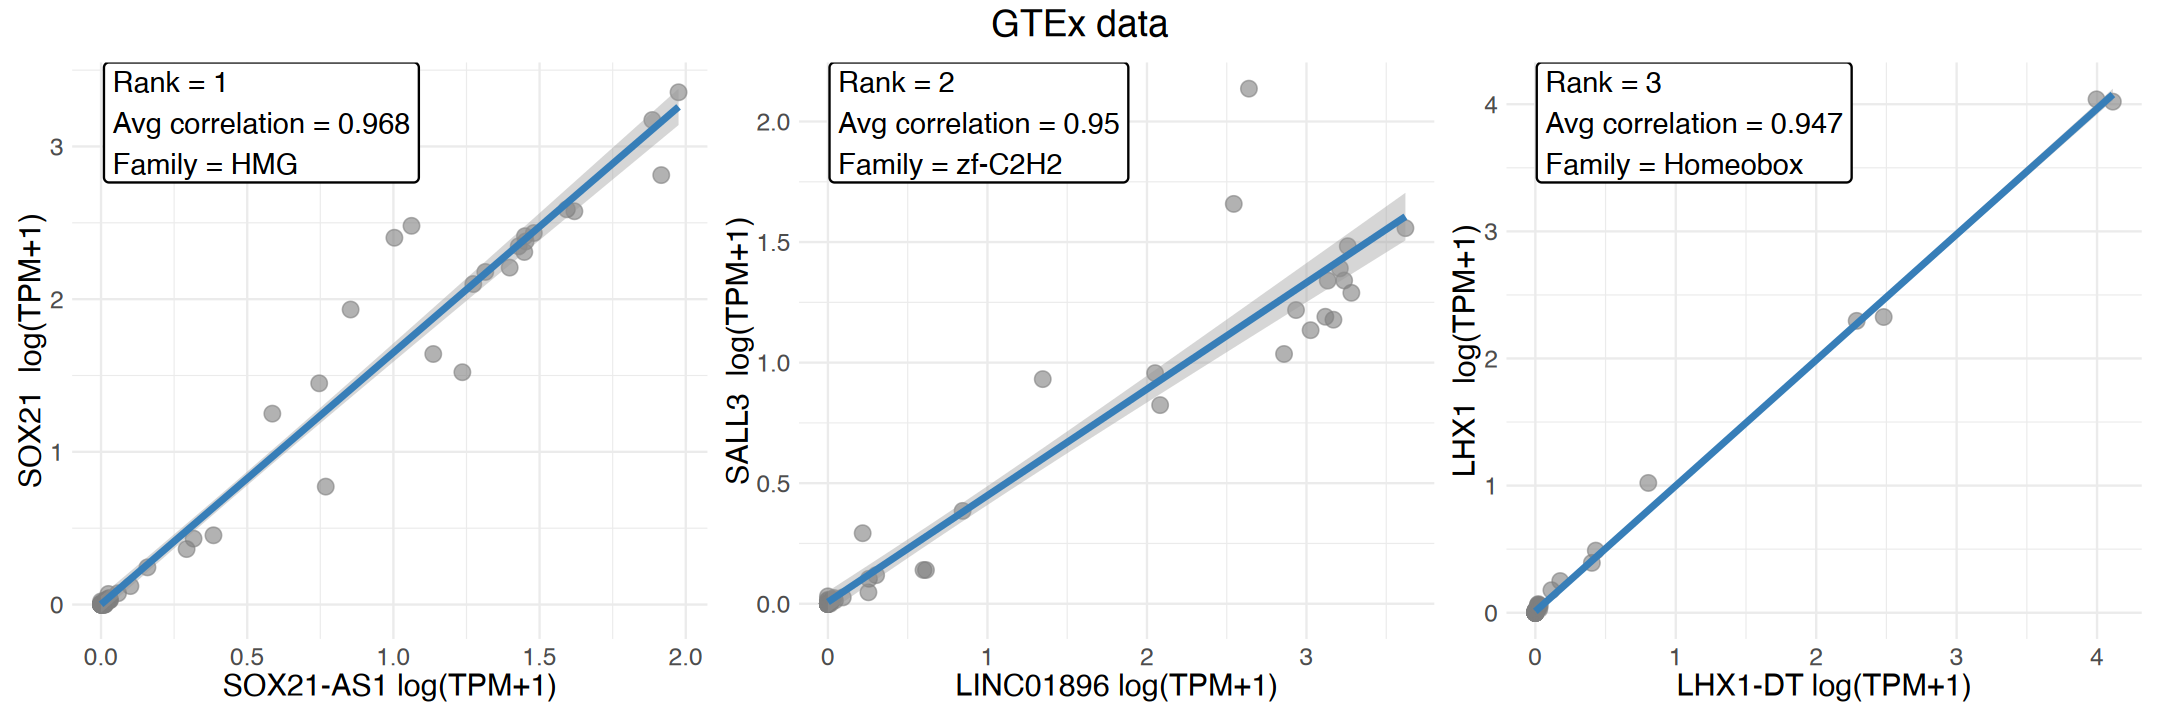

In [49]:
# change the plot size
options(repr.plot.width=18, repr.plot.height=6)
p_genes_encode <- wrap_plots(plot_list, nrow = 1) + plot_annotation(title = "GTEx data",
                                                        theme = theme(plot.title = element_text(size = text_size + 4, hjust = 0.5)))
print(p_genes_encode)

In [ ]:
# Save the plot
ggsave(filename = paste0(out_dir, "Plots/Correlation_plots_top3_gtex_", date, ".pdf"),
       plot = p_genes_encode,
       width = width*0.9, height = 5.0, units = "in", dpi = dpi)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
